In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

df = pd.read_csv('Employee.csv')
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


#### 1. Data Exploration: 


● Explore the data, list down the unique values in each feature and find its length.

● Perform the statistical analysis and renaming of the columns.

In [3]:

for col in df.columns:
    unique_vals = df[col].unique()
    print(f"Column: {col}")
    print(f"Unique Values: {unique_vals}")
    print(f"Length: {len(unique_vals)}\n")

# Statistical Analysis
print("Statistical Analysis:")
print(df.describe(include='all'))

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

Column: company
Unique Values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length: 7

Column: age
Unique Values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length: 30

Column: salary
Unique Values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Length: 41

Column: place
Unique Values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length: 12

Column: country
Unique Values: ['India']
Length: 1

Column: gender
Unique Values: [0 1]
Length: 2

Statistical Analysis:
       company         age       salary   place country      gender
count      140  130.000000   124.000000     134     148  148.000000
uniqu

#### 2. Data Cleaning: 


● Find the missing and inappropriate values, treat them appropriately.

● Remove all duplicate rows.

● Find the outliers.

● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

In [4]:

if 'age' in df.columns:
    df['age'] = df['age'].replace(0, np.nan)
df = df.drop_duplicates()

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"Outliers count in {col}: {len(outliers)}")

Outliers count in age: 0
Outliers count in salary: 0
Outliers count in gender: 32


#### 3. Data Analysis: 


● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
Count the number of people from each place and represent it visually

Filtered Data:
     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


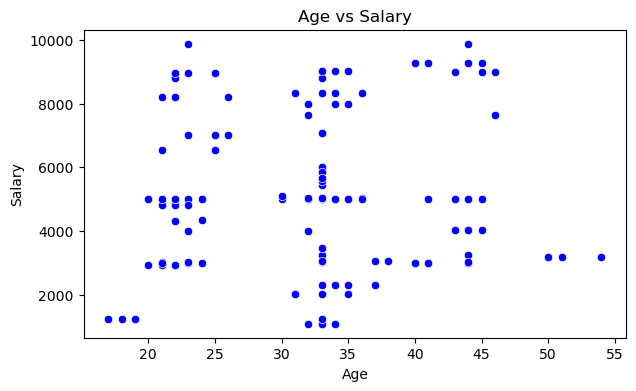

C:\Users\Nimish\AppData\Local\Temp\ipykernel_39484\1914845877.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='place', data=df, palette='viridis')


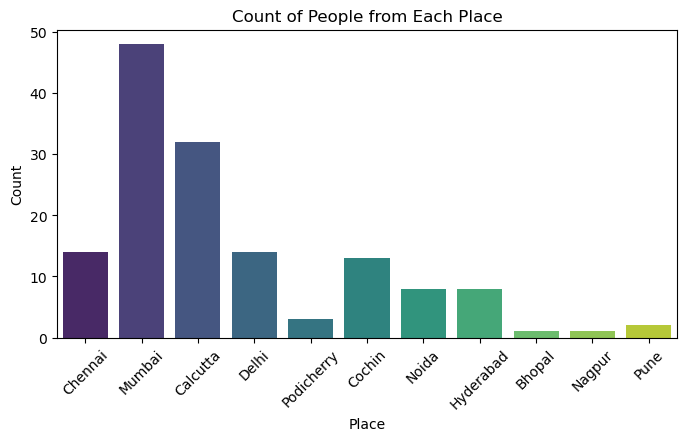

In [6]:

filtered_df = df[(df['age'] > 40) & (df['salary'] < 5000)]
print("Filtered Data:")
print(filtered_df)


plt.figure(figsize=(7, 4))
sns.scatterplot(x='age', y='salary', data=df, color='blue')
plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()


plt.figure(figsize=(8, 4))
sns.countplot(x='place', data=df, palette='viridis')
plt.title('Count of People from Each Place')
plt.xlabel('Place')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### 4. Data Encoding:


● Convert categorical variables into numerical representations using techniques
such as one-hot encoding, label encoding, making them suitable for analysis by
machine learning algorithms.

In [7]:

df_encoded = pd.get_dummies(df, columns=['place'], drop_first=True)

le = LabelEncoder()
for col in cat_cols:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,company,age,salary,country,gender,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune
0,4,20.0,5000.0,0,0,False,True,False,False,False,False,False,False,False,False
1,2,30.0,5000.0,0,0,False,False,False,False,False,True,False,False,False,False
2,4,35.0,2300.0,0,0,True,False,False,False,False,False,False,False,False,False
3,2,40.0,3000.0,0,0,False,False,False,True,False,False,False,False,False,False
4,4,23.0,4000.0,0,0,False,False,False,False,False,True,False,False,False,False


#### 5. Feature Scaling:


● After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

In [8]:

std_scaler = StandardScaler()
df_std = df_encoded.copy()
df_std[num_cols] = std_scaler.fit_transform(df_std[num_cols])

minmax_scaler = MinMaxScaler()
df_minmax = df_encoded.copy()
df_minmax[num_cols] = minmax_scaler.fit_transform(df_minmax[num_cols])

print("Standard Scaled Data:")
print(df_std.head())

print("\nMinMax Scaled Data:")
print(df_minmax.head())

Standard Scaled Data:
   company       age    salary  country    gender  place_Calcutta  \
0        4 -1.484676 -0.100827        0 -0.534522           False   
1        2 -0.267174 -0.100827        0 -0.534522           False   
2        4  0.341577 -1.243735        0 -0.534522            True   
3        2  0.950328 -0.947426        0 -0.534522           False   
4        4 -1.119426 -0.524127        0 -0.534522           False   

   place_Chennai  place_Cochin  place_Delhi  place_Hyderabad  place_Mumbai  \
0           True         False        False            False         False   
1          False         False        False            False          True   
2          False         False        False            False         False   
3          False         False         True            False         False   
4          False         False        False            False          True   

   place_Nagpur  place_Noida  place_Podicherry  place_Pune  
0         False        False     